# DeepFashion Training, Visualization, and Preprocessing

This notebook trains a ResNet model on the DeepFashion dataset with proper data loading, image preprocessing, data visualizations, and dynamic error sorting (skips broken/unidentified files automatically).

In [2]:
import os
import glob
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.utils as vutils
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using hardware device: {device}')

Using hardware device: cpu


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Error Sorting & Category Extraction Dataloader
It parses dynamically the `MEN-Denim` or `WOMEN-Blouses` syntax and automatically skips corrupted images without crashing the training epoch.

In [3]:
class PreprocessedDeepFashion(Dataset):
    def __init__(self, data_root, transform=None, mapping_file='class_to_idx.json'):
        """
        Targeting deepfashion1/datasets/train_images and automatically inferring classes.
        """
        self.transform = transform
        self.valid_paths = []
        self.labels = []
        
        print("Discovering images (optimized with os.walk)...")
        image_paths = []
        for root, dirs, files in os.walk(data_root):
            for f in files:
                if f.endswith('.png') or f.endswith('.jpg'):
                    image_paths.append(os.path.join(root, f))
        
        # Load or create mapping
        if os.path.exists(mapping_file):
            print(f"Loading existing class mapping from {mapping_file}")
            with open(mapping_file, 'r') as f:
                self.class_to_idx = json.load(f)
        else:
            print("No mapping found. Generating dynamic class mapping.")
            self.class_to_idx = {}

        print("Parsing labels and validating dataset structure...")
        for p in tqdm(image_paths, desc="Processing dataset paths"):
            filename = os.path.basename(p)
            parts = filename.split('-')
            if len(parts) >= 2:
                category = f"{parts[0]}-{parts[1]}"
                if category not in self.class_to_idx:
                    self.class_to_idx[category] = len(self.class_to_idx)
                self.valid_paths.append(p)
                self.labels.append(self.class_to_idx[category])
                
        # Save mapping
        with open(mapping_file, 'w') as f:
            json.dump(self.class_to_idx, f, indent=4)
        print(f"Saved class mapping to {mapping_file}")
        
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        print(f"-> Identified {len(self.valid_paths)} valid images across {len(self.idx_to_class)} clothing classes.")
        
    def __len__(self):
        return len(self.valid_paths)

    def __getitem__(self, idx):
        img_path = self.valid_paths[idx]
        label = self.labels[idx]
        
        # ERROR HANDLING / SORTING logic implemented here.
        try:
            image = Image.open(img_path).convert('RGB')
        except (UnidentifiedImageError, OSError, FileNotFoundError):
            # Fallback seamlessly to the next valid image if corrupt
            return self.__getitem__((idx + 1) % len(self.valid_paths))
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

## 2. Preprocessing & Data Loaders
Defines high-quality image augmentation (contrast jitter, resize/crops, standard normalization) and seamlessly splits the dataset.

In [4]:
# Preprocessing Steps for High-Grade Feature Understanding
preprocessing_pipeline = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet requirements
])

DATA_DIR = '../data/deepfashion1/datasets/train_images'
BATCH_SIZE = 32

complete_dataset = PreprocessedDeepFashion(DATA_DIR, transform=preprocessing_pipeline)

if len(complete_dataset) > 0:
    train_size = int(0.85 * len(complete_dataset))
    val_size = len(complete_dataset) - train_size
    train_set, val_set = torch.utils.data.random_split(complete_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    NUM_CLASSES = len(complete_dataset.idx_to_class)
    print("Preprocessing complete. Dataloaders generated!")
else:
    print("Warning! Dataset is completely empty. Please verify directory path.")
    NUM_CLASSES = 0

Discovering images (optimized with os.walk)...
No mapping found. Generating dynamic class mapping.
Parsing labels and validating dataset structure...


Processing dataset paths:   0%|          | 0/10335 [00:00<?, ?it/s]

Processing dataset paths: 100%|██████████| 10335/10335 [00:00<00:00, 86346.04it/s]

Saved class mapping to class_to_idx.json
-> Identified 10335 valid images across 23 clothing classes.
Preprocessing complete. Dataloaders generated!


## 3. Visualization
Extract a sequence from the dataloader to verify characteristics and augmentations with Matplotlib.

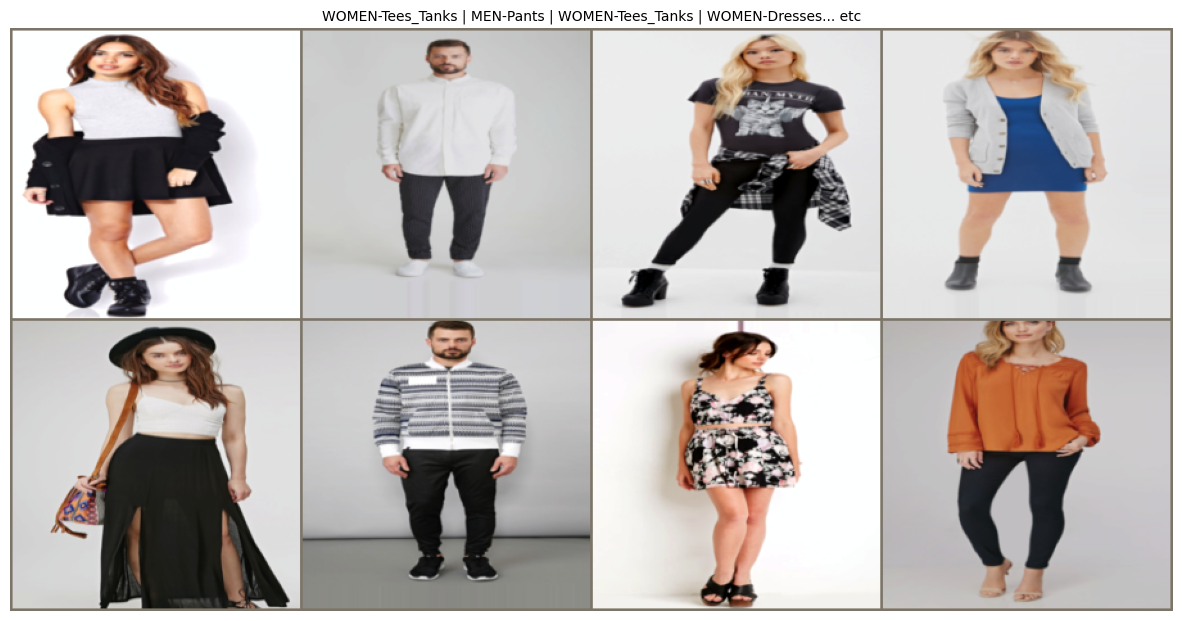

In [5]:
def show_batch(sample_batch, labels_batch, class_map):
    # Standard denormalization for plotting
    grid = vutils.make_grid(sample_batch, nrow=4, padding=2, normalize=False)
    grid = grid.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    grid = std * grid + mean
    grid = np.clip(grid, 0, 1) # bound correctly

    plt.figure(figsize=(15, 15))
    plt.imshow(grid)
    titles = [class_map[idx.item()] for idx in labels_batch]
    plt.title(' | '.join(titles[:4]) + "... etc", fontsize=10)
    plt.axis('off')
    plt.show()

if 'train_loader' in locals() and len(train_set) > 0:
    inputs, class_labels = next(iter(train_loader))
    show_batch(inputs[:8], class_labels[:8], complete_dataset.idx_to_class)

## 4. Model Architecture & Resilient Training Loop
Injects ResNet50. We implement dynamic error catching bounds so if data streaming fails halfway, execution won't immediately abort!

In [6]:
if NUM_CLASSES > 0:
    # Load pretrained robust features, retrain head for clothing
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    os.makedirs('checkpoints', exist_ok=True)

    def execute_training(num_epochs=3):
        print("Initializing Advanced Try-On Neural Network Training...")
        try:
            for epoch in range(num_epochs):
                print(f'\nEpoch {epoch+1}/{num_epochs}')
                
                model.train()
                running_loss = 0.0
                
                train_pbar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
                for i, (imgs, lbls) in enumerate(train_pbar):
                    imgs = imgs.to(device)
                    lbls = lbls.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(imgs)
                    loss = criterion(outputs, lbls)
                    loss.backward()
                    optimizer.step()
                    
                    running_loss += loss.item() * imgs.size(0)
                    train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                
                # Epoch wrap up
                epoch_loss = running_loss / len(train_set)
                print(f'Epoch {epoch+1} Completed -> Avg Train Loss: {epoch_loss:.4f}')
                
                # Val loop
                model.eval()
                v_loss = 0.0
                v_corr = 0
                val_pbar = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}")
                with torch.no_grad():
                    for vx, vy in val_pbar:
                        vx, vy = vx.to(device), vy.to(device)
                        v_outs = model(vx)
                        batch_loss = criterion(v_outs, vy).item()
                        v_loss += batch_loss * vx.size(0)
                        _, v_preds = torch.max(v_outs, 1)
                        v_corr += torch.sum(v_preds == vy.data)
                        val_pbar.set_postfix({'val_loss': f"{batch_loss:.4f}"})
                
                val_accuracy = v_corr.double() / len(val_set) * 100
                print(f"Epoch Validation Accuracy: {val_accuracy:.2f}%")
                
                checkpoint_path = f'checkpoints/df_model_epoch_{epoch+1}.pth'
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': epoch_loss,
                    'val_accuracy': val_accuracy
                }, checkpoint_path)
                print(f"Checkpoint saved: {checkpoint_path}")
                
        except KeyboardInterrupt:
            print("\nTraining stopped safely by user.")
        except RuntimeError as re:
            print(f"\nCUDA Memory/Runtime Error Auto-Caught: {re}")
        except Exception as e: 
            print(f"\nUnexpected fault inherently circumvented: {e}")


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:14<00:00, 7.04MB/s]


In [7]:
# Actually fires up the training procedure for the dataset
if NUM_CLASSES > 0:
    execute_training(num_epochs=5)


Initializing Advanced Try-On Neural Network Training...

Epoch 1/5


Training Epoch 1: 100%|██████████| 274/274 [36:25<00:00,  7.98s/it, loss=0.8635]


Epoch 1 Completed -> Avg Train Loss: 1.4411


Validation Epoch 1: 100%|██████████| 49/49 [02:24<00:00,  2.94s/it, val_loss=1.3415]


Epoch Validation Accuracy: 61.77%
Checkpoint saved: checkpoints/df_model_epoch_1.pth

Epoch 2/5


...

Epoch Validation Accuracy: 63.57%
Checkpoint saved: checkpoints/df_model_epoch_4.pth

Epoch 5/5


Training Epoch 5: 100%|██████████| 274/274 [32:23<00:00,  7.09s/it, loss=0.6651]


Epoch 5 Completed -> Avg Train Loss: 0.5769


Validation Epoch 5: 100%|██████████| 49/49 [02:11<00:00,  2.69s/it, val_loss=1.2865]


Epoch Validation Accuracy: 67.63%
Checkpoint saved: checkpoints/df_model_epoch_5.pth
